In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
import pandas as pd    
df=pd.read_excel("cleaned_loan_dataset.xlsx")
df

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,Sex Not Available,116500,NaN,118000.0,1740.0,758,25-34,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,NaN,NaN,4980.0,552,55-64,NaN,North,direct,1,NaN
2,24892,2019,Male,406500,4.56,508000.0,9480.0,834,35-44,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.25,658000.0,11880.0,587,45-54,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.00,758000.0,10440.0,602,25-34,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,NaN,248000.0,NaN,506,25-34,87.298387,North,direct,1,NaN
6996,31886,2019,Joint,306500,3.99,388000.0,4500.0,785,45-54,78.994845,central,direct,0,45.0
6997,31887,2019,Female,386500,4.56,418000.0,6120.0,775,35-44,92.464115,North,direct,0,30.0
6998,31888,2019,Male,756500,NaN,3808000.0,11280.0,746,55-64,19.866071,North,direct,1,60.0


In [3]:
df.shape

(7000, 14)

In [4]:
df.rename(columns = {'dtir1':'Debt to income ratio'} )

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,Debt to income ratio
0,24890,2019,Sex Not Available,116500,NaN,118000.0,1740.0,758,25-34,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,NaN,NaN,4980.0,552,55-64,NaN,North,direct,1,NaN
2,24892,2019,Male,406500,4.56,508000.0,9480.0,834,35-44,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.25,658000.0,11880.0,587,45-54,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.00,758000.0,10440.0,602,25-34,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,NaN,248000.0,NaN,506,25-34,87.298387,North,direct,1,NaN
6996,31886,2019,Joint,306500,3.99,388000.0,4500.0,785,45-54,78.994845,central,direct,0,45.0
6997,31887,2019,Female,386500,4.56,418000.0,6120.0,775,35-44,92.464115,North,direct,0,30.0
6998,31888,2019,Male,756500,NaN,3808000.0,11280.0,746,55-64,19.866071,North,direct,1,60.0


In [5]:

df.rename(columns = {'dtir1':'Debt to income ratio'} )

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,Debt to income ratio
0,24890,2019,Sex Not Available,116500,NaN,118000.0,1740.0,758,25-34,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,NaN,NaN,4980.0,552,55-64,NaN,North,direct,1,NaN
2,24892,2019,Male,406500,4.56,508000.0,9480.0,834,35-44,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.25,658000.0,11880.0,587,45-54,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.00,758000.0,10440.0,602,25-34,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,NaN,248000.0,NaN,506,25-34,87.298387,North,direct,1,NaN
6996,31886,2019,Joint,306500,3.99,388000.0,4500.0,785,45-54,78.994845,central,direct,0,45.0
6997,31887,2019,Female,386500,4.56,418000.0,6120.0,775,35-44,92.464115,North,direct,0,30.0
6998,31888,2019,Male,756500,NaN,3808000.0,11280.0,746,55-64,19.866071,North,direct,1,60.0


In [6]:
df

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,Sex Not Available,116500,NaN,118000.0,1740.0,758,25-34,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,NaN,NaN,4980.0,552,55-64,NaN,North,direct,1,NaN
2,24892,2019,Male,406500,4.56,508000.0,9480.0,834,35-44,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.25,658000.0,11880.0,587,45-54,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.00,758000.0,10440.0,602,25-34,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,NaN,248000.0,NaN,506,25-34,87.298387,North,direct,1,NaN
6996,31886,2019,Joint,306500,3.99,388000.0,4500.0,785,45-54,78.994845,central,direct,0,45.0
6997,31887,2019,Female,386500,4.56,418000.0,6120.0,775,35-44,92.464115,North,direct,0,30.0
6998,31888,2019,Male,756500,NaN,3808000.0,11280.0,746,55-64,19.866071,North,direct,1,60.0


In [7]:
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
6995    False
6996    False
6997    False
6998    False
6999    False
Length: 7000, dtype: bool>

In [8]:
df.isnull().sum()

ID                     0
year                   0
Gender                 0
loan_amount            0
rate_of_interest    1723
property_value       747
income               416
Credit_Score           0
age                    7
LTV                  747
Region                 0
Security_Type          0
Status                 0
dtir1               1158
dtype: int64

In [9]:
y=df.rate_of_interest.median()
y

3.99

In [10]:
x=df.rate_of_interest.mean()
x

np.float64(4.039598256585181)

In [11]:
df['rate_of_interest'].fillna(y,inplace=True)


C:\Users\Asus\AppData\Local\Temp\ipykernel_21392\3104092124.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rate_of_interest'].fillna(y,inplace=True)


In [12]:
df

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,Sex Not Available,116500,3.99,118000.0,1740.0,758,25-34,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,3.99,NaN,4980.0,552,55-64,NaN,North,direct,1,NaN
2,24892,2019,Male,406500,4.56,508000.0,9480.0,834,35-44,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.25,658000.0,11880.0,587,45-54,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.00,758000.0,10440.0,602,25-34,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,3.99,248000.0,NaN,506,25-34,87.298387,North,direct,1,NaN
6996,31886,2019,Joint,306500,3.99,388000.0,4500.0,785,45-54,78.994845,central,direct,0,45.0
6997,31887,2019,Female,386500,4.56,418000.0,6120.0,775,35-44,92.464115,North,direct,0,30.0
6998,31888,2019,Male,756500,3.99,3808000.0,11280.0,746,55-64,19.866071,North,direct,1,60.0


In [13]:
z=df.property_value.mean()
z

np.float64(500138.1736766352)

In [14]:
q=df.property_value.median()
q

418000.0

In [15]:
df['property_value'].fillna(z,inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_21392\1343371694.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['property_value'].fillna(z,inplace=True)


In [16]:
df

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,Sex Not Available,116500,3.99,1.180000e+05,1740.0,758,25-34,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,3.99,5.001382e+05,4980.0,552,55-64,NaN,North,direct,1,NaN
2,24892,2019,Male,406500,4.56,5.080000e+05,9480.0,834,35-44,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.25,6.580000e+05,11880.0,587,45-54,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.00,7.580000e+05,10440.0,602,25-34,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,3.99,2.480000e+05,NaN,506,25-34,87.298387,North,direct,1,NaN
6996,31886,2019,Joint,306500,3.99,3.880000e+05,4500.0,785,45-54,78.994845,central,direct,0,45.0
6997,31887,2019,Female,386500,4.56,4.180000e+05,6120.0,775,35-44,92.464115,North,direct,0,30.0
6998,31888,2019,Male,756500,3.99,3.808000e+06,11280.0,746,55-64,19.866071,North,direct,1,60.0


In [17]:
p=df.income.mean()
p

np.float64(6936.925880923451)

In [18]:
m=df.income.median()
m

5760.0

In [19]:
df['income'].fillna(m,inplace=True)
df

C:\Users\Asus\AppData\Local\Temp\ipykernel_21392\4045802568.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(m,inplace=True)


,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,Sex Not Available,116500,3.99,1.180000e+05,1740.0,758,25-34,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,3.99,5.001382e+05,4980.0,552,55-64,NaN,North,direct,1,NaN
2,24892,2019,Male,406500,4.56,5.080000e+05,9480.0,834,35-44,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.25,6.580000e+05,11880.0,587,45-54,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.00,7.580000e+05,10440.0,602,25-34,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,3.99,2.480000e+05,5760.0,506,25-34,87.298387,North,direct,1,NaN
6996,31886,2019,Joint,306500,3.99,3.880000e+05,4500.0,785,45-54,78.994845,central,direct,0,45.0
6997,31887,2019,Female,386500,4.56,4.180000e+05,6120.0,775,35-44,92.464115,North,direct,0,30.0
6998,31888,2019,Male,756500,3.99,3.808000e+06,11280.0,746,55-64,19.866071,North,direct,1,60.0


In [20]:
df.head(20)

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,Sex Not Available,116500,3.990,1.180000e+05,1740.0,758,25-34,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,3.990,5.001382e+05,4980.0,552,55-64,NaN,North,direct,1,NaN
2,24892,2019,Male,406500,4.560,5.080000e+05,9480.0,834,35-44,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.250,6.580000e+05,11880.0,587,45-54,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.000,7.580000e+05,10440.0,602,25-34,91.886544,North,direct,0,39.0
5,24895,2019,Joint,706500,3.990,1.008000e+06,10080.0,864,35-44,70.089286,North,direct,0,40.0
6,24896,2019,Joint,346500,4.500,4.380000e+05,5040.0,860,55-64,79.109589,North,direct,0,44.0
7,24897,2019,Female,266500,4.125,3.080000e+05,3780.0,863,55-64,86.525974,North,direct,0,42.0
8,24898,2019,Joint,376500,4.875,4.780000e+05,5580.0,580,55-64,78.765690,central,direct,0,44.0
9,24899,2019,Sex Not Available,436500,3.490,6.880000e+05,6720.0,788,55-64,63.444767,south,direct,0,30.0


In [21]:
d=df.LTV.mean()
d

np.float64(72.8773376790152)

In [22]:
df.fillna(d,inplace=True)

In [23]:
h=df.dtir1.mean()
h

np.float64(43.57213671889994)

In [24]:
df.fillna(h,inplace=True)

In [25]:
df.drop(columns="age")

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,Sex Not Available,116500,3.99,1.180000e+05,1740.0,758,98.728814,south,direct,1,45.000000
1,24891,2019,Male,206500,3.99,5.001382e+05,4980.0,552,72.877338,North,direct,1,72.877338
2,24892,2019,Male,406500,4.56,5.080000e+05,9480.0,834,80.019685,south,direct,0,46.000000
3,24893,2019,Male,456500,4.25,6.580000e+05,11880.0,587,69.376900,North,direct,0,42.000000
4,24894,2019,Joint,696500,4.00,7.580000e+05,10440.0,602,91.886544,North,direct,0,39.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,3.99,2.480000e+05,5760.0,506,87.298387,North,direct,1,72.877338
6996,31886,2019,Joint,306500,3.99,3.880000e+05,4500.0,785,78.994845,central,direct,0,45.000000
6997,31887,2019,Female,386500,4.56,4.180000e+05,6120.0,775,92.464115,North,direct,0,30.000000
6998,31888,2019,Male,756500,3.99,3.808000e+06,11280.0,746,19.866071,North,direct,1,60.000000


In [26]:
df

,ID,year,Gender,loan_amount,rate_of_interest,property_value,income,Credit_Score,age,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,Sex Not Available,116500,3.99,1.180000e+05,1740.0,758,25-34,98.728814,south,direct,1,45.000000
1,24891,2019,Male,206500,3.99,5.001382e+05,4980.0,552,55-64,72.877338,North,direct,1,72.877338
2,24892,2019,Male,406500,4.56,5.080000e+05,9480.0,834,35-44,80.019685,south,direct,0,46.000000
3,24893,2019,Male,456500,4.25,6.580000e+05,11880.0,587,45-54,69.376900,North,direct,0,42.000000
4,24894,2019,Joint,696500,4.00,7.580000e+05,10440.0,602,25-34,91.886544,North,direct,0,39.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,31885,2019,Joint,216500,3.99,2.480000e+05,5760.0,506,25-34,87.298387,North,direct,1,72.877338
6996,31886,2019,Joint,306500,3.99,3.880000e+05,4500.0,785,45-54,78.994845,central,direct,0,45.000000
6997,31887,2019,Female,386500,4.56,4.180000e+05,6120.0,775,35-44,92.464115,North,direct,0,30.000000
6998,31888,2019,Male,756500,3.99,3.808000e+06,11280.0,746,55-64,19.866071,North,direct,1,60.000000


In [27]:
df.isnull().sum()

ID                  0
year                0
Gender              0
loan_amount         0
rate_of_interest    0
property_value      0
income              0
Credit_Score        0
age                 0
LTV                 0
Region              0
Security_Type       0
Status              0
dtir1               0
dtype: int64

In [28]:
df.describe()

,ID,year,loan_amount,rate_of_interest,property_value,income,Credit_Score,LTV,Status,dtir1
count,7000.000000,7000.0,7.000000e+03,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,28389.500000,2019.0,3.343500e+05,4.027390,5.001382e+05,6866.982857,700.757571,72.877338,0.247143,43.572137
std,2020.870275,0.0,1.896331e+05,0.475027,3.520371e+05,5922.525713,115.576511,17.510531,0.431381,16.168240
min,24890.000000,2019.0,2.650000e+04,2.375000,3.800000e+04,0.000000,500.000000,2.813745,0.000000,5.000000
25%,26639.750000,2019.0,1.965000e+05,3.750000,2.880000e+05,3900.000000,601.000000,64.182058,0.000000,33.000000
50%,28389.500000,2019.0,2.965000e+05,3.990000,4.680000e+05,5760.000000,699.500000,73.026316,0.000000,42.000000
75%,30139.250000,2019.0,4.365000e+05,4.250000,5.980000e+05,8160.000000,801.000000,84.722222,0.000000,49.000000
max,31889.000000,2019.0,3.576500e+06,6.240000,6.508000e+06,189360.000000,900.000000,201.315789,1.000000,72.877338


In [29]:
df.count()

ID                  7000
year                7000
Gender              7000
loan_amount         7000
rate_of_interest    7000
property_value      7000
income              7000
Credit_Score        7000
age                 7000
LTV                 7000
Region              7000
Security_Type       7000
Status              7000
dtir1               7000
dtype: int64

In [30]:
df["LTV"].min()

2.81374502

In [31]:
df["LTV"].max()

201.3157895

In [32]:
df["LTV"].std()

17.510531458577702

<Axes: xlabel='LTV'>

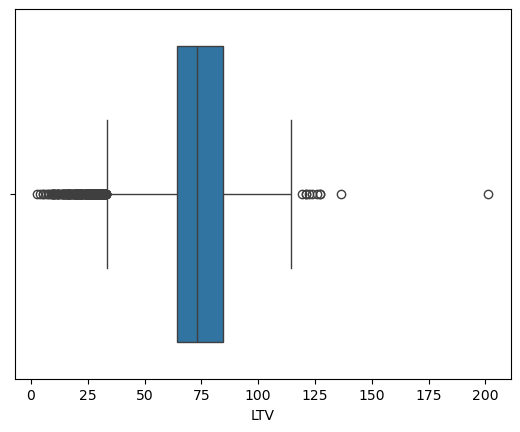

In [33]:
#boxplot
sns.boxplot(x="LTV",data=df)

<Axes: xlabel='dtir1', ylabel='count'>

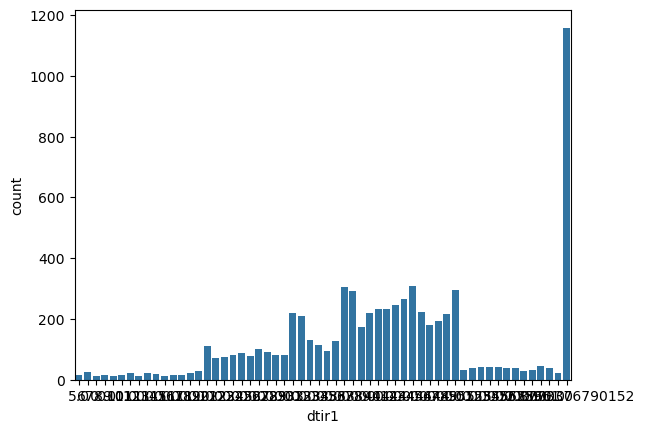

In [34]:
#countplot
sns.countplot(x="dtir1",data=df)


<Axes: xlabel='Credit_Score', ylabel='Region'>

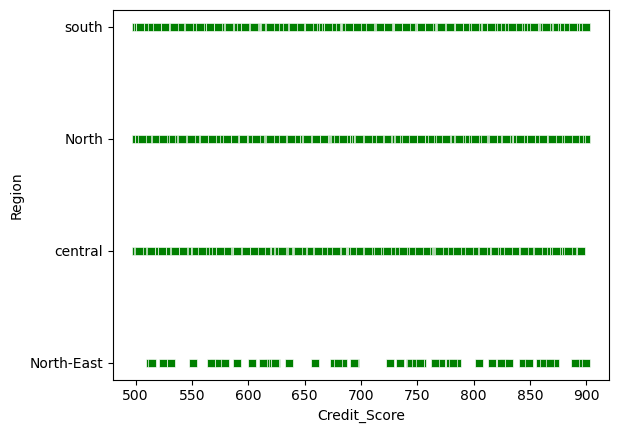

In [35]:
#scatter plot
sns.scatterplot(x="Credit_Score",y="Region",data=df,color="g",marker="s")

<Axes: xlabel='income', ylabel='Credit_Score'>

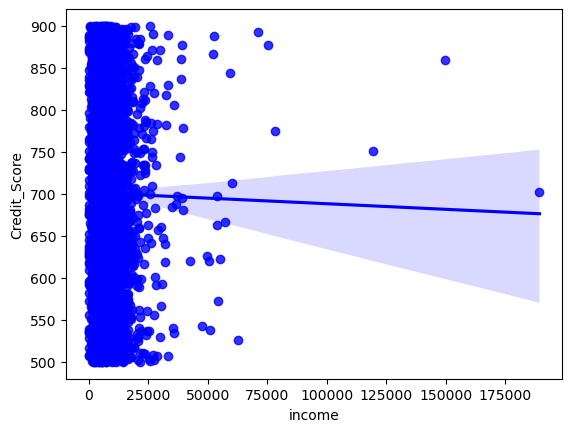

In [36]:
#regression
sns.regplot(x="income",y="Credit_Score",data=df,color="b")

In [53]:
#heatmap
sns.heatmap(df.corr(numeric_only),annot=True)
x=df[["LTV","Credit_Score","income"]]
y=df["Status"]

NameError: name 'numeric_only' is not defined

In [226]:
x=df[["Credit_Score", "income", "rate_of_interest", "property_value","dtir1","LTV"]]
y=df["loan_amount"]
x
y

0       116500
1       206500
2       406500
3       456500
4       696500
         ...  
6995    216500
6996    306500
6997    386500
6998    756500
6999    436500
Name: loan_amount, Length: 7000, dtype: int64

In [227]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=52)

In [228]:
x_train

,Credit_Score,income,rate_of_interest,property_value,dtir1,LTV
1577,755,1860.0,3.99,128000.0,45.0,98.828125
1644,547,3900.0,3.75,238000.0,41.0,78.361345
3649,734,12420.0,4.99,708000.0,37.0,68.714689
3213,563,1980.0,3.99,328000.0,40.0,38.567073
4072,643,7200.0,3.75,518000.0,35.0,88.127413
...,...,...,...,...,...,...
924,900,7800.0,3.99,498000.0,47.0,95.682731
6230,686,8400.0,4.75,588000.0,36.0,94.642857
4247,753,22740.0,3.25,1408000.0,30.0,53.728693
2827,783,14100.0,3.99,858000.0,54.0,80.011655


In [229]:
y_train

1577    126500
1644    186500
3649    486500
3213    126500
4072    456500
         ...  
924     476500
6230    556500
4247    756500
2827    686500
1692    186500
Name: loan_amount, Length: 4900, dtype: int64

In [230]:
x_test


,Credit_Score,income,rate_of_interest,property_value,dtir1,LTV
6590,539,5760.0,3.000,4.180000e+05,72.877338,97.248804
4472,573,6840.0,3.750,1.368000e+06,31.000000,27.521930
4565,697,14340.0,3.990,5.001382e+05,72.877338,72.877338
4532,546,8460.0,3.990,3.980000e+05,21.000000,82.035176
6080,536,8520.0,4.500,5.480000e+05,40.000000,90.602190
...,...,...,...,...,...,...
2212,595,3600.0,4.500,1.380000e+05,29.000000,84.420290
168,781,2640.0,3.990,1.180000e+05,44.000000,98.728814
3700,708,8100.0,3.875,3.280000e+05,32.000000,81.250000
338,577,5760.0,4.000,6.180000e+05,36.000000,75.485437


In [231]:
y_test

6590    406500
4472    376500
4565    416500
4532    326500
6080    496500
         ...  
2212    116500
168     116500
3700    266500
338     466500
6436    476500
Name: loan_amount, Length: 2100, dtype: int64

In [232]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train =scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[-1.38205267, -0.18656266, -2.17475983, -0.23061458,  1.80914724,
         1.38818552],
       [-1.09025978,  0.0035984 , -0.59097718,  2.48418629, -0.78077785,
        -2.59824162],
       [-0.02607395,  1.3241613 , -0.08416674,  0.00411046,  1.80914724,
        -0.00518075],
       ...,
       [ 0.06832963,  0.22545297, -0.32701341, -0.48780624, -0.71893235,
         0.47350138],
       [-1.05593121, -0.18656266, -0.06304963,  0.34092245, -0.47155033,
         0.14392959],
       [ 0.21422607,  0.17263045, -1.64683228,  1.45541965, -0.71893235,
        -1.46909994]], shape=(2100, 6))

In [233]:
#applying linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

regression= LinearRegression()
regression=regression.fit(x_train,y_train)

y_pred = regression.predict(x_test)
score= r2_score(y_test,y_pred)
print(score)

0.5866298311398395


In [234]:
regression.predict(scaler.transform([[587,11880,4.25,658000,69.3769,42]]))

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([314989.16828726])

In [235]:
df["Status"].unique()

array([1, 0])

In [191]:
k=df[["Credit_Score","income", "loan_amount", "rate_of_interest", "property_value","dtir1","LTV"]]
o=df["Status"]
k
o

0       1
1       1
2       0
3       0
4       0
       ..
6995    1
6996    0
6997    0
6998    1
6999    0
Name: Status, Length: 7000, dtype: int64

In [183]:
from sklearn.linear_model import LogisticRegression

In [184]:
classifier= LogisticRegression()

In [193]:
from sklearn.model_selection import train_test_split

k_train,k_test,o_train,o_test=train_test_split(k,o,test_size=0.30,random_state=52)

In [201]:
classifier.fit(k_train,o_train)

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [204]:
o_pred=classifier.predict(k_test)

In [205]:
o_pred

array([1, 0, 1, ..., 0, 0, 0], shape=(2100,))

In [206]:
o_test

6590    0
4472    0
4565    1
4532    0
6080    0
       ..
2212    0
168     1
3700    0
338     0
6436    0
Name: Status, Length: 2100, dtype: int64

In [207]:
from sklearn.metrics import accuracy_score,classification_report

In [208]:
print(accuracy_score(o_pred,o_test))

0.82


In [209]:
print(classification_report(o_pred,o_test))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1808
           1       0.42      0.73      0.53       292

    accuracy                           0.82      2100
   macro avg       0.68      0.78      0.71      2100
weighted avg       0.88      0.82      0.84      2100

